“Exploratory Data Analysis on Diabetes Patients”

## Question 1: What is the proportion of patients diagnosed with diabetes?

In this section, we will calculate and visualize the percentage of patients who were diagnosed with diabetes (Outcome = 1) compared to those who were not (Outcome = 0).

Understanding this proportion helps us get an overview of the dataset balance and the prevalence of diabetes in this sample.

**Key points to cover:**
- Count and percentage for each Outcome.
- Pie chart or bar plot to show the distribution.
- Comment on whether the classes are balanced or imbalanced.
- 
_Reference: [CDC - Diabetes Statistics](https://www.cdc.gov/diabetes/data/index.html)_

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
Di = pd.read_csv("/Users/hayaalbuhaisi/Desktop/AIProf/diabetes.csv")
Di.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [15]:
Di.shape

(768, 9)

In [17]:
Di.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [19]:
Di.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
Di.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

> **Note:** Zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` columns were treated as missing values and replaced with the median of each column, following standard practice for the Pima Indians Diabetes dataset ([UCI ML Repository](https://archive.ics.uci.edu/ml/datasets/pima+indians+diabetes)).

## 📌 Question 1: What is the percentage of patients diagnosed with diabetes versus those without?

In this section, we will calculate and visualize the percentage of patients who are diagnosed with diabetes (`Outcome = 1`) compared to those who are not (`Outcome = 0`).

This helps us understand the balance of the dataset and the overall prevalence of diabetes in this sample.

_Reference: [CDC - National Diabetes Statistics Report](https://www.cdc.gov/diabetes/data/statistics-report/index.html)_

In [41]:
outcome_counts = Di['Outcome'].value_counts()
outcome_percentages = outcome_counts / outcome_counts.sum() * 100

print("Counts:")
print(outcome_counts)

print("\nPercentages:")
print(outcome_percentages)

Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentages:
Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64


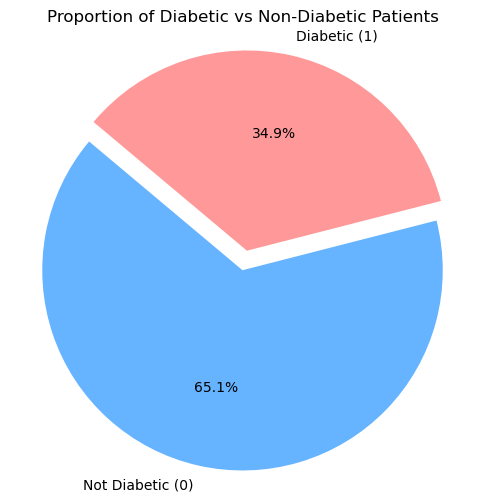

In [43]:
outcome_counts = Di['Outcome'].value_counts()
labels = ['Not Diabetic (0)', 'Diabetic (1)']
colors = ['#66b3ff', '#ff9999']
plt.figure(figsize=(6, 6))
plt.pie(outcome_counts, labels=labels, autopct='%1.1f%%', startangle=140,
        colors=colors, explode=(0, 0.1))
plt.title('Proportion of Diabetic vs Non-Diabetic Patients')
plt.axis('equal')
plt.show()

## 📊 Pie Chart: Distribution of Diabetic vs Non-Diabetic Patients

This pie chart visualizes the proportion of patients who are diagnosed with diabetes (`Outcome = 1`) versus those who are not (`Outcome = 0`).

It helps to quickly understand the balance of the dataset and how the target variable is distributed.

- **Labels:** `Not Diabetic (0)` and `Diabetic (1)`
- **Visual:** Exploded slice highlights the diabetic group for better focus.
- **Purpose:** Supports the calculation shown previously and provides a clear visual summary.

_Reference: [CDC - National Diabetes Statistics Report](https://www.cdc.gov/diabetes/data/statistics-report/index.html)_

## 📌 Question 2: What is the relationship between the number of pregnancies and the risk of diabetes?

In this section, we will analyze the relationship between the number of pregnancies (`Pregnancies`) and the likelihood of being diagnosed with diabetes (`Outcome`).

A **swarm plot** will be used to clearly show how the number of pregnancies is distributed across the two `Outcome` classes (0 = Not Diabetic, 1 = Diabetic).

**Key points to include:**
- The X-axis shows the `Outcome` (0 or 1).
- The Y-axis shows the `Pregnancies` count.
- The swarm plot helps avoid overlapping points and visualizes the spread effectively.
- This visual makes it easier to observe if higher pregnancy counts are associated with higher diabetes risk.

_Reference: [CDC - Gestational Diabetes](https://www.cdc.gov/diabetes/basics/gestational.html)_

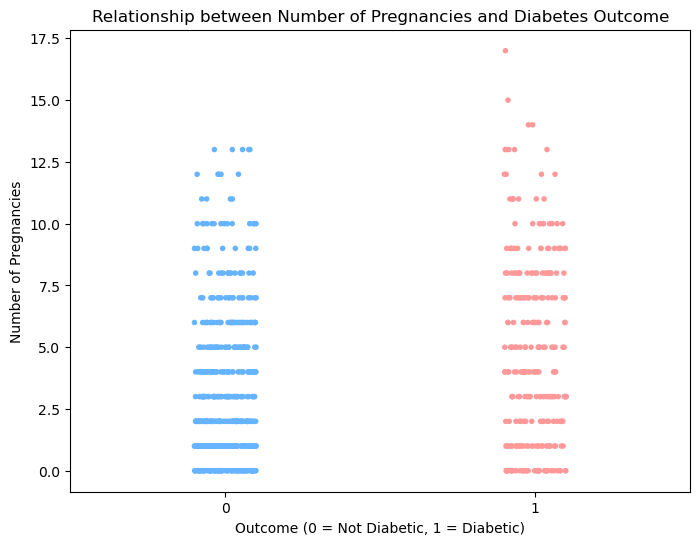

In [55]:
plt.figure(figsize=(8, 6))
sns.stripplot(data=Di, x='Outcome', y='Pregnancies', hue='Outcome',
              palette=['#66b3ff', '#ff9999'],
              dodge=False, jitter=True, size=4, legend=False)

plt.title('Relationship between Number of Pregnancies and Diabetes Outcome')
plt.xlabel('Outcome (0 = Not Diabetic, 1 = Diabetic)')
plt.ylabel('Number of Pregnancies')
plt.show()

## 📊 Strip Plot: Relationship between Number of Pregnancies and Diabetes Outcome

This strip plot shows the distribution of the number of pregnancies (`Pregnancies`) for patients with and without diabetes (`Outcome`).

- **X-axis:** Outcome (0 = Not Diabetic, 1 = Diabetic)
- **Y-axis:** Number of pregnancies
- **Colors:** Different colors for each outcome to highlight the split
- **Jitter:** A slight jitter was added to spread overlapping points for better visibility

**Insights:**  
This visualization helps to observe if patients diagnosed with diabetes tend to have a higher number of pregnancies compared to those who are not diagnosed.

_Reference: [CDC - Gestational Diabetes](https://www.cdc.gov/diabetes/basics/gestational.html)_

## 📌 Question 3: Is there a relationship between BMI and the risk of diabetes?

In this section, we will investigate whether there is a clear relationship between the Body Mass Index (`BMI`) and the likelihood of being diagnosed with diabetes (`Outcome`).

A **box plot** will be used to compare the BMI distribution between patients diagnosed with diabetes (`Outcome = 1`) and those who are not (`Outcome = 0`).

**Key points to include:**
- **X-axis:** Outcome (0 = Not Diabetic, 1 = Diabetic)
- **Y-axis:** BMI values
- The box plot shows the median, quartiles, and outliers for each group.
- This visual helps reveal if higher BMI is associated with a greater risk of diabetes.

_Reference: [CDC - BMI and Diabetes Risk](https://www.cdc.gov/diabetes/basics/risk-factors.html)_

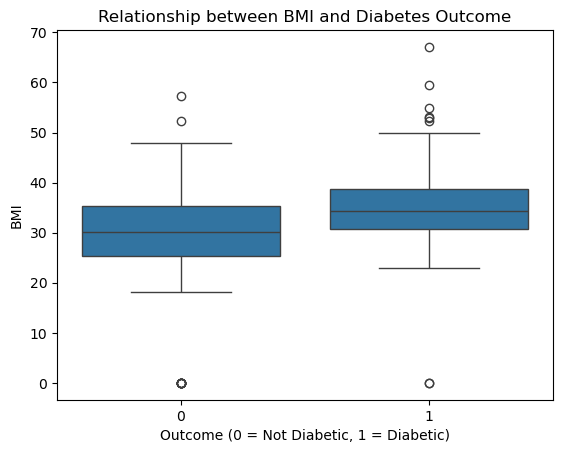

In [65]:
sns.boxplot(x='Outcome',y='BMI',data=Di);
plt.title('Relationship between BMI and Diabetes Outcome')
plt.xlabel('Outcome (0 = Not Diabetic, 1 = Diabetic)')
plt.ylabel('BMI')
plt.show()

### ✅ Result: Relationship between BMI and Diabetes Outcome

The box plot shows that patients diagnosed with diabetes (`Outcome = 1`) tend to have a slightly higher median BMI compared to those who are not diagnosed (`Outcome = 0`).

- The median BMI for the diabetic group appears higher.
- The overall spread (interquartile range) is wider for the diabetic group.
- There are some outliers with very high BMI values in both groups.
- This suggests that higher BMI may be associated with an increased risk of diabetes in this dataset.

_Reference: [CDC - BMI and Diabetes Risk](https://www.cdc.gov/diabetes/basics/risk-factors.html)_

## 📌 Question 4: How does the genetic factor (Diabetes Pedigree Function) affect the outcome?

In this section, we will examine how the **Diabetes Pedigree Function** (a numeric measure of genetic risk) relates to the likelihood of being diagnosed with diabetes (`Outcome`).

A box plot will be used to compare the distribution of the `DiabetesPedigreeFunction` for patients who are diagnosed with diabetes (`Outcome = 1`) versus those who are not (`Outcome = 0`).

**Key points to include:**
- **X-axis:** Outcome (0 = Not Diabetic, 1 = Diabetic)
- **Y-axis:** Diabetes Pedigree Function value
- The box plot will show if patients with a higher genetic risk score tend to be more likely to develop diabetes.

_Reference: [American Diabetes Association - Risk Factors](https://diabetes.org/diabetes/risk-factors)_

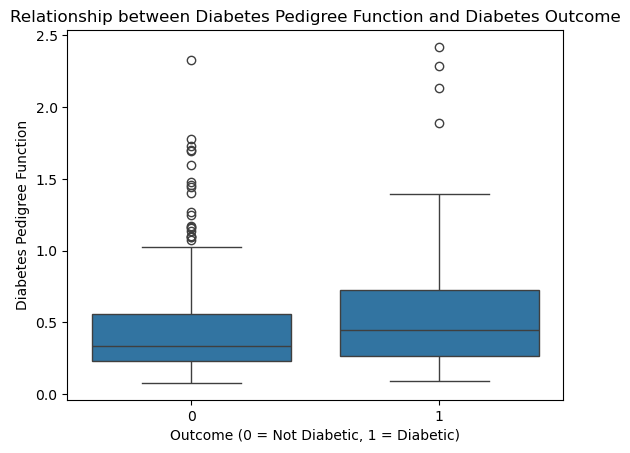

In [73]:
sns.boxplot(x='Outcome',y='DiabetesPedigreeFunction',data=Di);
plt.title('Relationship between Diabetes Pedigree Function and Diabetes Outcome')
plt.xlabel('Outcome (0 = Not Diabetic, 1 = Diabetic)')
plt.ylabel('Diabetes Pedigree Function')
plt.show()

### ✅ Result: Relationship between Diabetes Pedigree Function and Diabetes Outcome

The box plot shows that patients diagnosed with diabetes (`Outcome = 1`) tend to have a slightly higher **Diabetes Pedigree Function** compared to those who are not diagnosed (`Outcome = 0`).

- The median value of the genetic factor is visibly higher for the diabetic group.
- There is a wider spread in the diabetic group, with some high outliers indicating strong family history.
- This suggests that genetic predisposition plays a role in the likelihood of developing diabetes in this sample.

_Reference: [American Diabetes Association - Risk Factors](https://diabetes.org/diabetes/risk-factors)_

## 📌 Question 5: Does the risk of diabetes increase with age? (Age Group Analysis)

In this section, we will investigate whether patients diagnosed with diabetes tend to be older compared to those who are not diagnosed.

A **box plot** will be used to compare the age distribution between `Outcome = 0` (Not Diabetic) and `Outcome = 1` (Diabetic).

**Key points to include:**
- **X-axis:** Outcome (0 or 1)
- **Y-axis:** Age
- The box plot will show if the median age and spread are higher for the diabetic group.
- This helps confirm whether age is a significant factor in this dataset.

_Reference: [CDC - Diabetes Risk Factors](https://www.cdc.gov/diabetes/basics/risk-factors.html)_

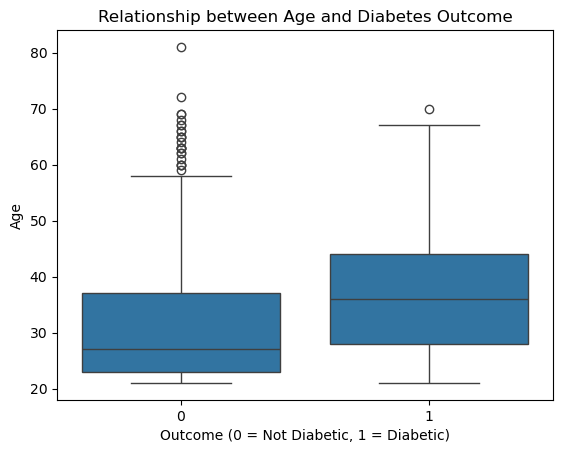

In [78]:
sns.boxplot(x='Outcome',y='Age',data=Di);
plt.title('Relationship between Age and Diabetes Outcome')
plt.xlabel('Outcome (0 = Not Diabetic, 1 = Diabetic)')
plt.ylabel('Age')
plt.show()

### ✅ Result: Relationship between Age and Diabetes Outcome

The box plot shows that patients diagnosed with diabetes (`Outcome = 1`) generally have a higher median age than those who are not diagnosed (`Outcome = 0`).

- The median age for the diabetic group is visibly higher.
- The age range (interquartile range) also shifts higher for the diabetic group.
- This suggests that in this dataset, older patients are more likely to be diagnosed with diabetes.

_Reference: [CDC - Diabetes Risk Factors](https://www.cdc.gov/diabetes/basics/risk-factors.html)_

### ✅ Overall Conclusion
The analysis shows that age, BMI, number of pregnancies, and genetic factors are all related to the likelihood of diabetes in this dataset.